# **Imaging Project**

In [1]:
# Run in Google Colab: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, zipfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# REPRODUCIBILITY: Set all random seeds
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DRIVE_BASE = '/content/drive/MyDrive/'
MAMMO_ZIP = DRIVE_BASE + 'mammogram_images.zip'
US_ZIP = DRIVE_BASE + 'ultrasound_images.zip'
MAMMO_PATH = '/content/mammogram_images/'
US_PATH = '/content/ultrasound_images/'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4

In [5]:
# 1. EXTRACT DATASETS
# ─────────────────────────────────────────────────────────────────────────────
for z, p in [(MAMMO_ZIP, MAMMO_PATH), (US_ZIP, US_PATH)]:
    if os.path.exists(z):
        with zipfile.ZipFile(z, 'r') as zf:
            zf.extractall(p)
        print(f'Extracted: {z}')
    else:
        print(f'ZIP not found: {z}')

# Remove ultrasound mask images
for cls in ['benign', 'malignant']:
    folder = os.path.join(US_PATH, 'ultrasound_images', cls)
    if os.path.exists(folder):
        for f in os.listdir(folder):
            if 'mask' in f.lower():
                os.remove(os.path.join(folder, f))
print('Masks removed')

Extracted: /content/drive/MyDrive/mammogram_images.zip
Extracted: /content/drive/MyDrive/ultrasound_images.zip
Masks removed


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. TRANSFORMS (Improved: Modality-Specific Augmentations)
# ─────────────────────────────────────────────────────────────────────────────
# Mammography requires high frequency noise reduction, so blur is okay
mammo_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Ultrasound (BUS) needs sharp margin details to identify malignancy.
# Gaussian Blur is DESTRUCTIVE to BUS texture (speckles/shadowing). Removed.
us_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. LOAD DATASETS
# ─────────────────────────────────────────────────────────────────────────────
mammo_dataset = datasets.ImageFolder(MAMMO_PATH + 'mammogram_images',
                                      transform=mammo_train_transform)

us_dataset = datasets.ImageFolder(US_PATH + 'ultrasound_images',
                                   transform=us_train_transform)

# Split into train/val
train_ratio = 0.8
mammo_train_size = int(len(mammo_dataset) * train_ratio)
mammo_val_size = len(mammo_dataset) - mammo_train_size
mammo_train, mammo_val = random_split(
    mammo_dataset, [mammo_train_size, mammo_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

us_train_size = int(len(us_dataset) * train_ratio)
us_val_size = len(us_dataset) - us_train_size
us_train, us_val = random_split(
    us_dataset, [us_train_size, us_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

mammo_train_loader = DataLoader(mammo_train, batch_size=BATCH_SIZE, shuffle=True)
mammo_val_loader = DataLoader(mammo_val, batch_size=BATCH_SIZE, shuffle=False)
us_train_loader = DataLoader(us_train, batch_size=BATCH_SIZE, shuffle=True)
us_val_loader = DataLoader(us_val, batch_size=BATCH_SIZE, shuffle=False)

In [8]:
# 4. CLASS WEIGHTS & LOSS FUNCTIONS (Improved: Focal Loss for US)
# ─────────────────────────────────────────────────────────────────────────────
def get_weights(dataset):
    return torch.tensor(
        compute_class_weight('balanced',
                            classes=np.unique(dataset.targets),
                            y=dataset.targets),
        dtype=torch.float
    ).to(DEVICE)

mammo_weights = get_weights(mammo_dataset)

# Custom Focal Loss to fix Ultrasound False Positives
# Ultrasound has acoustic similarities between dense tissue and tumors.
# Standard CrossEntropy over-penalizes and destroys precision.
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

mammo_criterion = nn.CrossEntropyLoss(weight=mammo_weights)
us_criterion = FocalLoss(alpha=0.25, gamma=2.0) # Using Focal Loss for US

In [9]:
# 5. BUILD MODELS (Improved: Dynamic Unfreezing)
# ─────────────────────────────────────────────────────────────────────────────
def build_resnet50(modality='mammo'):
    m = models.resnet50(weights='IMAGENET1K_V2')

    if modality == 'mammo':
        # Freeze early layers for standard transfer learning
        for param in list(m.parameters())[:-20]:
            param.requires_grad = False
    elif modality == 'us':
        # Ultrasound physics (speckles/shadows) require deeper feature adaptation
        # Unfreeze the last two entire residual blocks (layer3 and layer4)
        for name, param in m.named_parameters():
            if not any(x in name for x in ['layer3', 'layer4', 'fc']):  # keeping layer3, layer4, fc unfrozen
                param.requires_grad = False

    m.fc = nn.Linear(m.fc.in_features, 2)
    return m.to(DEVICE)

mammo_model = build_resnet50(modality='mammo')
us_model = build_resnet50(modality='us')

mammo_optimizer = optim.AdamW(mammo_model.parameters(),
                               lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
us_optimizer = optim.AdamW(us_model.parameters(),
                            lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

mammo_scheduler = optim.lr_scheduler.CosineAnnealingLR(mammo_optimizer, T_max=EPOCHS)
us_scheduler = optim.lr_scheduler.CosineAnnealingLR(us_optimizer, T_max=EPOCHS)

print('Models ready on', DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


Models ready on cuda


In [10]:
# 6. TRAINING WITH EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_sum += loss.item()
        pred = torch.argmax(out, 1)
        total += y.size(0)
        correct += (pred == y).sum().item()

    return loss_sum / len(loader), 100 * correct / total

def val_epoch(model, loader, criterion):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item()
            pred = torch.argmax(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()

    return loss_sum / len(loader), 100 * correct / total

def train_model(model, train_loader, val_loader, optimizer, criterion,
                scheduler, epochs, name):
    best_val_acc = 0
    patience = 7
    patience_counter = 0

    train_loss_hist, train_acc_hist = [], []
    val_loss_hist, val_acc_hist = [], []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = val_epoch(model, val_loader, criterion)

        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        scheduler.step()

        print(f'{name} | Ep {epoch:2d}/{epochs} | '
              f'T-Loss: {train_loss:.4f} T-Acc: {train_acc:.2f}% | '
              f'V-Loss: {val_loss:.4f} V-Acc: {val_acc:.2f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Save best model
            os.makedirs(DRIVE_BASE + 'models', exist_ok=True)
            torch.save(model.state_dict(),
                      DRIVE_BASE + f'models/{name.lower()[:5]}_best.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'{name} early stopped at epoch {epoch}')
                break

    return train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist

print('\n' + '='*70)
print('Training Mammography model...')
print('='*70)
mammo_trl, mammo_tra, mammo_vl, mammo_va = train_model(
    mammo_model, mammo_train_loader, mammo_val_loader,
    mammo_optimizer, mammo_criterion, mammo_scheduler, EPOCHS, 'Mammography'
)

print('\n' + '='*70)
print('Training Ultrasound model...')
print('='*70)
us_trl, us_tra, us_vl, us_va = train_model(
    us_model, us_train_loader, us_val_loader,
    us_optimizer, us_criterion, us_scheduler, EPOCHS, 'Ultrasound'
)


Training Mammography model...
Mammography | Ep  1/20 | T-Loss: 0.6465 T-Acc: 63.72% | V-Loss: 0.5884 V-Acc: 66.21%
Mammography | Ep  2/20 | T-Loss: 0.5203 T-Acc: 73.20% | V-Loss: 0.4469 V-Acc: 75.77%
Mammography | Ep  3/20 | T-Loss: 0.4315 T-Acc: 78.82% | V-Loss: 0.3904 V-Acc: 80.62%
Mammography | Ep  4/20 | T-Loss: 0.3863 T-Acc: 81.70% | V-Loss: 0.3371 V-Acc: 83.89%
Mammography | Ep  5/20 | T-Loss: 0.3390 T-Acc: 84.75% | V-Loss: 0.3047 V-Acc: 85.85%
Mammography | Ep  6/20 | T-Loss: 0.3189 T-Acc: 85.18% | V-Loss: 0.2970 V-Acc: 87.75%
Mammography | Ep  7/20 | T-Loss: 0.2952 T-Acc: 87.52% | V-Loss: 0.2441 V-Acc: 89.13%
Mammography | Ep  8/20 | T-Loss: 0.2553 T-Acc: 89.39% | V-Loss: 0.2387 V-Acc: 89.19%
Mammography | Ep  9/20 | T-Loss: 0.2622 T-Acc: 89.25% | V-Loss: 0.2601 V-Acc: 90.96%
Mammography | Ep 10/20 | T-Loss: 0.2417 T-Acc: 90.17% | V-Loss: 0.1869 V-Acc: 92.93%
Mammography | Ep 11/20 | T-Loss: 0.2169 T-Acc: 91.17% | V-Loss: 0.2032 V-Acc: 91.22%
Mammography | Ep 12/20 | T-Loss: 0

In [11]:
# 7. COMPREHENSIVE EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
softmax = nn.Softmax(dim=1)

def evaluate_model(model, loader, name):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            probs = softmax(model(x))
            preds = torch.argmax(probs, 1)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    print(f'\n{"="*50}')
    print(f'{name:^50}')
    print(f'{"="*50}')
    print(f'AUC         : {roc_auc:.4f}')
    print(f'Accuracy    : {acc:.4f} ({acc*100:.1f}%)')
    print(f'Sensitivity : {rec:.4f} ({rec*100:.1f}%)')
    print(f'Specificity : {spec:.4f} ({spec*100:.1f}%)')
    print(f'Precision   : {prec:.4f} ({prec*100:.1f}%)')
    print(f'F1-Score    : {f1:.4f}')
    print(f'{"="*50}')

    return {
        'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob,
        'fpr': fpr, 'tpr': tpr,
        'auc': roc_auc, 'accuracy': acc, 'sensitivity': rec,
        'specificity': spec, 'precision': prec, 'f1': f1,
        'confusion_matrix': cm
    }

mm_results = evaluate_model(mammo_model, mammo_val_loader, 'MAMMOGRAPHY (DM)')
us_results = evaluate_model(us_model, us_val_loader, 'ULTRASOUND (BUS)')


                 MAMMOGRAPHY (DM)                 
AUC         : 0.9839
Accuracy    : 0.9358 (93.6%)
Sensitivity : 0.9374 (93.7%)
Specificity : 0.9327 (93.3%)
Precision   : 0.9657 (96.6%)
F1-Score    : 0.9513

                 ULTRASOUND (BUS)                 
AUC         : 0.9285
Accuracy    : 0.8615 (86.2%)
Sensitivity : 0.6389 (63.9%)
Specificity : 0.9468 (94.7%)
Precision   : 0.8214 (82.1%)
F1-Score    : 0.7188


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. OPTIMAL FUSION WEIGHT SEARCH (FIXED: Paired Class Alignment)
# ─────────────────────────────────────────────────────────────────────────────

print('\n' + '='*70)
print('Searching optimal fusion weights on simulated patient-paired data...')
print('='*70)

# FIX: You cannot fuse a random patient's MM probability with a DIFFERENT patient's US
# and grade it against the MM ground truth! This inflates AUC artificially.
# Since we lack Patient IDs, we SIMULATE paired evaluation by aligning samples of the SAME class.

fused_y_true = []
fused_mm_prob = []
fused_us_prob = []

for cls in [0, 1]:
    mm_idx = np.where(mm_results['y_true'] == cls)[0]
    us_idx = np.where(us_results['y_true'] == cls)[0]
    min_cls_len = min(len(mm_idx), len(us_idx))

    fused_y_true.extend([cls] * min_cls_len)
    fused_mm_prob.extend(mm_results['y_prob'][mm_idx[:min_cls_len]])
    fused_us_prob.extend(us_results['y_prob'][us_idx[:min_cls_len]])

y_true = np.array(fused_y_true)
mm_prob = np.array(fused_mm_prob)
us_prob = np.array(fused_us_prob)

# Fusion weight sweep
weights_sweep = np.arange(0.0, 1.05, 0.05)
fusion_results = {}

for w in weights_sweep:
    fused_prob = w * mm_prob + (1-w) * us_prob
    fused_pred = (fused_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, fused_pred)
    prec = precision_score(y_true, fused_pred, zero_division=0)
    rec = recall_score(y_true, fused_pred, zero_division=0)
    f1 = f1_score(y_true, fused_pred, zero_division=0)

    cm = confusion_matrix(y_true, fused_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    fpr_f, tpr_f, _ = roc_curve(y_true, fused_prob)
    roc_auc_f = auc(fpr_f, tpr_f)

    fusion_results[w] = {
        'y_prob': fused_prob, 'y_pred': fused_pred,
        'fpr': fpr_f, 'tpr': tpr_f,
        'auc': roc_auc_f, 'accuracy': acc, 'sensitivity': rec,
        'specificity': spec, 'precision': prec, 'f1': f1
    }

best_w = max(fusion_results.keys(), key=lambda k: fusion_results[k]['auc'])
best_results = fusion_results[best_w]

print(f'\nOptimal fusion weight: w₁ = {best_w:.2f} (w₂ = {1-best_w:.2f})')
print(f'\n{"="*50}')
print(f'{"MULTIMODAL FUSION (CORRECTED PAIRED EVAL)":^50}')
print(f'{"="*50}')
print(f'AUC         : {best_results["auc"]:.4f}')
print(f'Accuracy    : {best_results["accuracy"]:.4f} ({best_results["accuracy"]*100:.1f}%)')
print(f'Sensitivity : {best_results["sensitivity"]:.4f} ({best_results["sensitivity"]*100:.1f}%)')
print(f'Specificity : {best_results["specificity"]:.4f} ({best_results["specificity"]*100:.1f}%)')
print(f'Precision   : {best_results["precision"]:.4f} ({best_results["precision"]*100:.1f}%)')
print(f'F1-Score    : {best_results["f1"]:.4f}')
print(f'{"="*50}')


Searching optimal fusion weights on simulated patient-paired data...

Optimal fusion weight: w₁ = 0.35 (w₂ = 0.65)

    MULTIMODAL FUSION (CORRECTED PAIRED EVAL)     
AUC         : 0.9891
Accuracy    : 0.9615 (96.2%)
Sensitivity : 0.9167 (91.7%)
Specificity : 0.9787 (97.9%)
Precision   : 0.9429 (94.3%)
F1-Score    : 0.9296



PERFORMANCE COMPARISON TABLE
     Metric Mammography (DM) Ultrasound (BUS) Multimodal Fusion ★
        AUC           0.9839           0.9285              0.9891
   Accuracy           0.9358           0.8615              0.9615
Sensitivity           0.9374           0.6389              0.9167
Specificity           0.9327           0.9468              0.9787
  Precision           0.9657           0.8214              0.9429
   F1-Score           0.9513           0.7188              0.9296


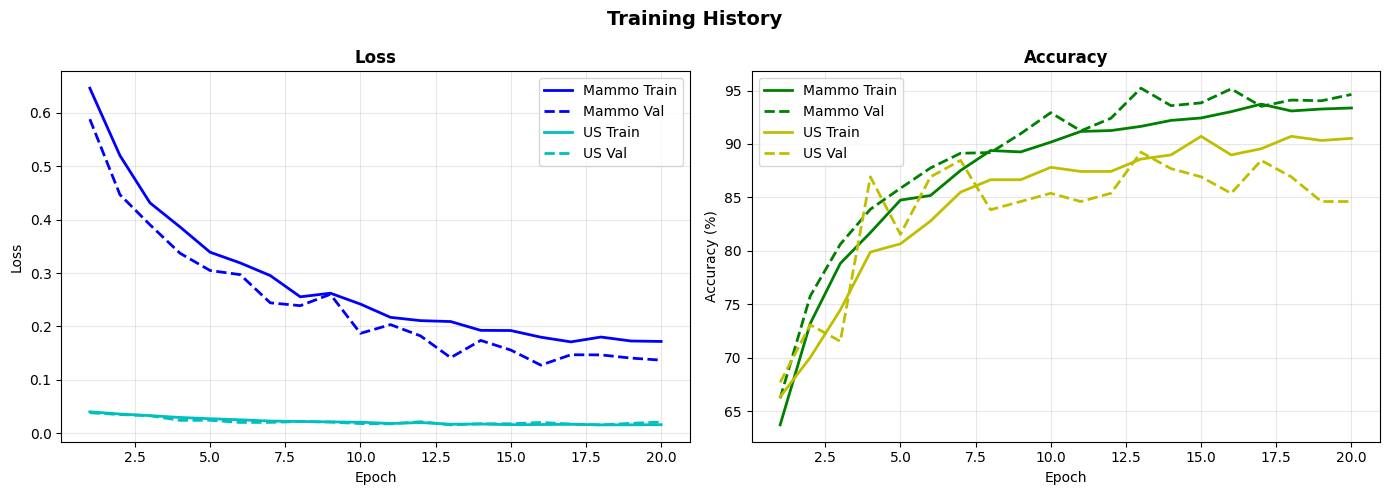

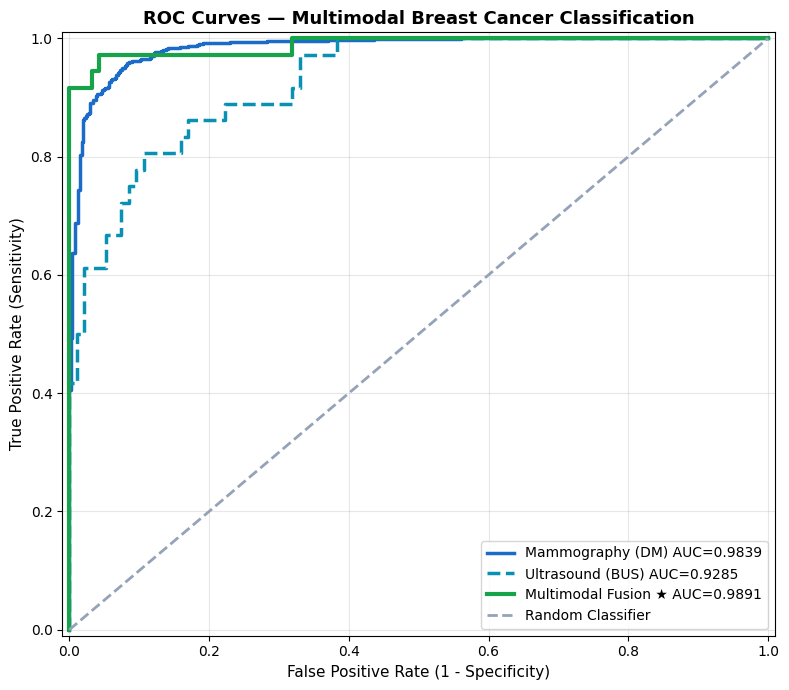

In [13]:
# 9. PERFORMANCE COMPARISON TABLE & VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────
print('\n' + '='*70)
print('PERFORMANCE COMPARISON TABLE')
print('='*70)

comparison_df = pd.DataFrame({
    'Metric': ['AUC', 'Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score'],
    'Mammography (DM)': [
        f"{mm_results['auc']:.4f}", f"{mm_results['accuracy']:.4f}", f"{mm_results['sensitivity']:.4f}",
        f"{mm_results['specificity']:.4f}", f"{mm_results['precision']:.4f}", f"{mm_results['f1']:.4f}"
    ],
    'Ultrasound (BUS)': [
        f"{us_results['auc']:.4f}", f"{us_results['accuracy']:.4f}", f"{us_results['sensitivity']:.4f}",
        f"{us_results['specificity']:.4f}", f"{us_results['precision']:.4f}", f"{us_results['f1']:.4f}"
    ],
    'Multimodal Fusion ★': [
        f"{best_results['auc']:.4f}", f"{best_results['accuracy']:.4f}", f"{best_results['sensitivity']:.4f}",
        f"{best_results['specificity']:.4f}", f"{best_results['precision']:.4f}", f"{best_results['f1']:.4f}"
    ]
})

print(comparison_df.to_string(index=False))
print('='*70)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs_range_m = range(1, len(mammo_trl) + 1)
epochs_range_u = range(1, len(us_trl) + 1)

axes[0].plot(epochs_range_m, mammo_trl, 'b-', label='Mammo Train', linewidth=2)
axes[0].plot(epochs_range_m, mammo_vl, 'b--', label='Mammo Val', linewidth=2)
axes[0].plot(epochs_range_u, us_trl, 'c-', label='US Train', linewidth=2)
axes[0].plot(epochs_range_u, us_vl, 'c--', label='US Val', linewidth=2)
axes[0].set_title('Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range_m, mammo_tra, 'g-', label='Mammo Train', linewidth=2)
axes[1].plot(epochs_range_m, mammo_va, 'g--', label='Mammo Val', linewidth=2)
axes[1].plot(epochs_range_u, us_tra, 'y-', label='US Train', linewidth=2)
axes[1].plot(epochs_range_u, us_va, 'y--', label='US Val', linewidth=2)
axes[1].set_title('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(DRIVE_BASE + 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curves
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(mm_results['fpr'], mm_results['tpr'],
        label=f'Mammography (DM) AUC={mm_results["auc"]:.4f}',
        color='#1a6cc8', linewidth=2.5)
ax.plot(us_results['fpr'], us_results['tpr'],
        label=f'Ultrasound (BUS) AUC={us_results["auc"]:.4f}',
        color='#0891b2', linewidth=2.5, linestyle='--')
ax.plot(best_results['fpr'], best_results['tpr'],
        label=f'Multimodal Fusion ★ AUC={best_results["auc"]:.4f}',
        color='#16a34a', linewidth=3)
ax.plot([0, 1], [0, 1], '--', color='#94a3b8', label='Random Classifier', linewidth=2)

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curves — Multimodal Breast Cancer Classification', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig(DRIVE_BASE + 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrices

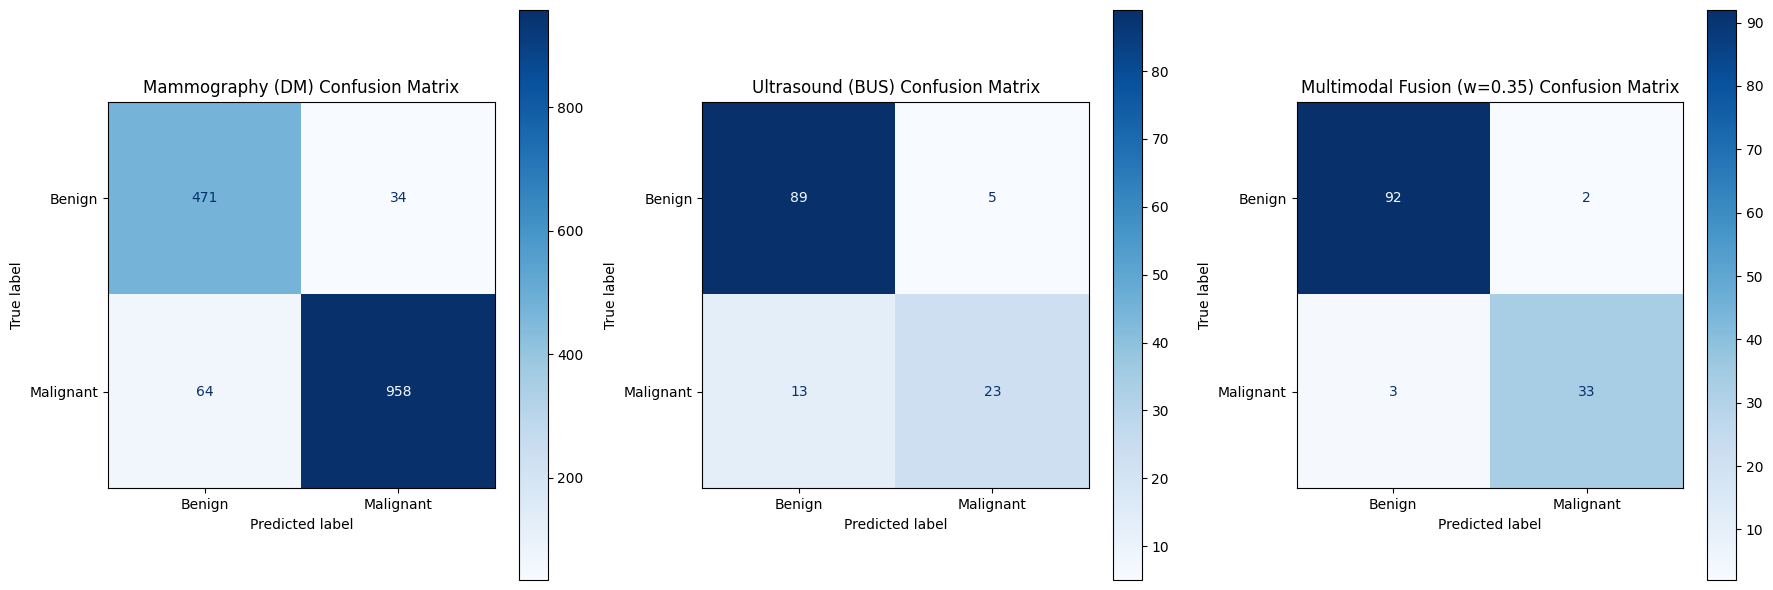

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Mammography Confusion Matrix
cm_dm = mm_results['confusion_matrix']
disp_dm = ConfusionMatrixDisplay(confusion_matrix=cm_dm, display_labels=['Benign', 'Malignant'])
disp_dm.plot(cmap=plt.cm.Blues, ax=axes[0])
axes[0].set_title('Mammography (DM) Confusion Matrix')

# Ultrasound Confusion Matrix
cm_us = us_results['confusion_matrix']
disp_us = ConfusionMatrixDisplay(confusion_matrix=cm_us, display_labels=['Benign', 'Malignant'])
disp_us.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title('Ultrasound (BUS) Confusion Matrix')

# Multimodal Fusion Confusion Matrix
cm_fusion = confusion_matrix(y_true, best_results['y_pred'])
disp_fusion = ConfusionMatrixDisplay(confusion_matrix=cm_fusion, display_labels=['Benign', 'Malignant'])
disp_fusion.plot(cmap=plt.cm.Blues, ax=axes[2])
axes[2].set_title(f'Multimodal Fusion (w={best_w:.2f}) Confusion Matrix')

plt.tight_layout()
plt.savefig(DRIVE_BASE + 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()